In [2]:
!pip install shap xgboost plotly

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split

shap.initjs()

In [4]:
X, y = shap.datasets.adult()
X_display, y_display = shap.datasets.adult(display=True)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
d_train = xgb.DMatrix(X_train, label=y_train)
d_test = xgb.DMatrix(X_test, label=y_test)

In [11]:
params = {
    "eta": 0.05,
    "objective": "binary:logistic",
    "subsample": 0.8,
    "base_score": np.mean(y_train),
    "eval_metric": "logloss",
}

model = xgb.train(
    params,
    d_train,
    evals=[(d_test, "test")],
    verbose_eval=100,
    early_stopping_rounds=20,
)

[0]	test-logloss:0.53091
[9]	test-logloss:0.41761


In [12]:
from sklearn.metrics import accuracy_score

y_pred_prob = model.predict(d_test)
y_pred = (y_pred_prob>0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 81.59%


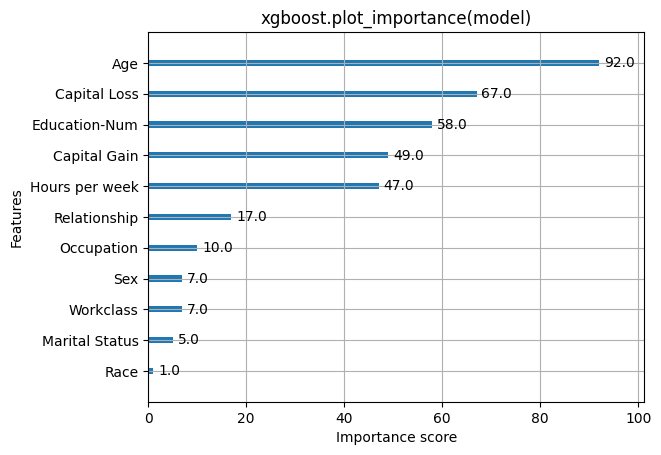

In [13]:
xgb.plot_importance(model)
plt.title("xgboost.plot_importance(model)")
plt.show()

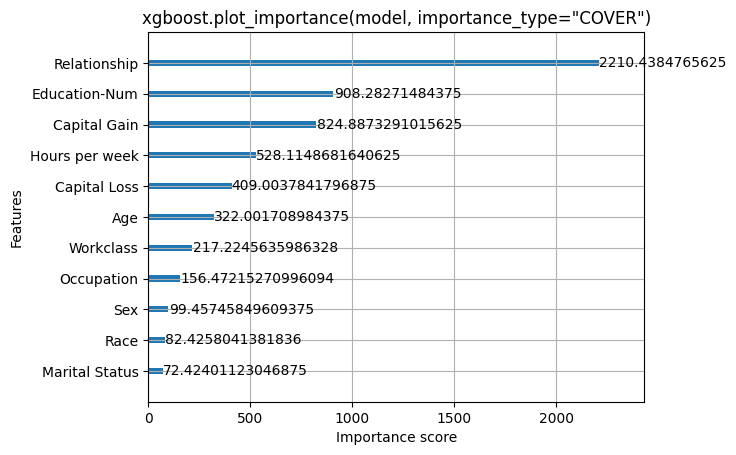

In [15]:
xgb.plot_importance(model, importance_type="cover")
plt.title('xgboost.plot_importance(model, importance_type="COVER")')
plt.show()

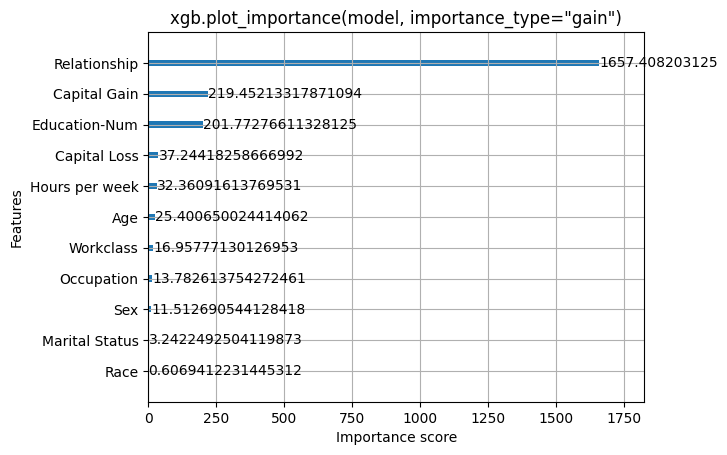

In [16]:
xgb.plot_importance(model, importance_type="gain")
plt.title('xgb.plot_importance(model, importance_type="gain")')
plt.show()

In [17]:
explainer=shap.TreeExplainer(model)
shap_values=explainer.shap_values(X)

In [18]:
import plotly.io as pio

# pio.renderers.default = 'colab'

shap.initjs()

shap.force_plot(explainer.expected_value, shap_values[0, :], X_display.iloc[0, :])

In [19]:
shap.initjs()

shap.force_plot(
    explainer.expected_value, shap_values[:1000, :], X_display.iloc[:1000, :]
)

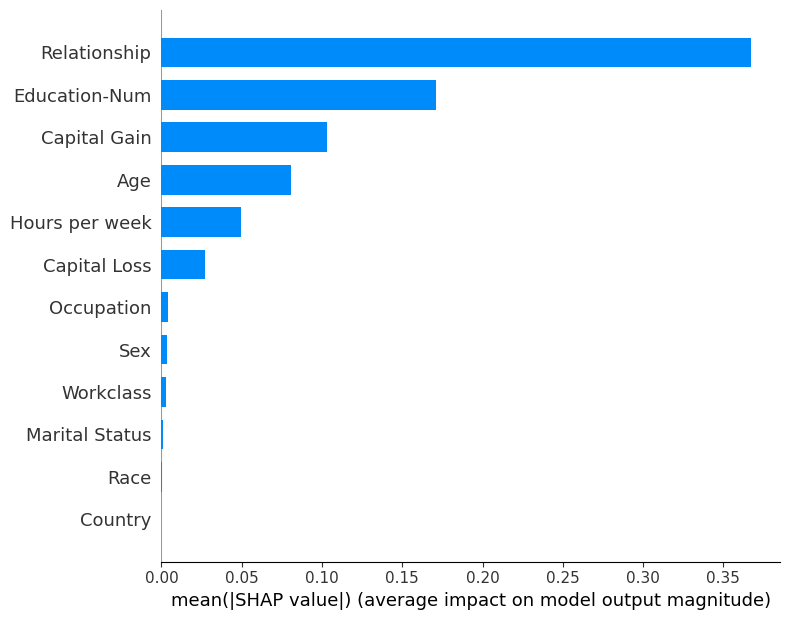

In [20]:
shap.summary_plot(shap_values, X_display, plot_type='bar')

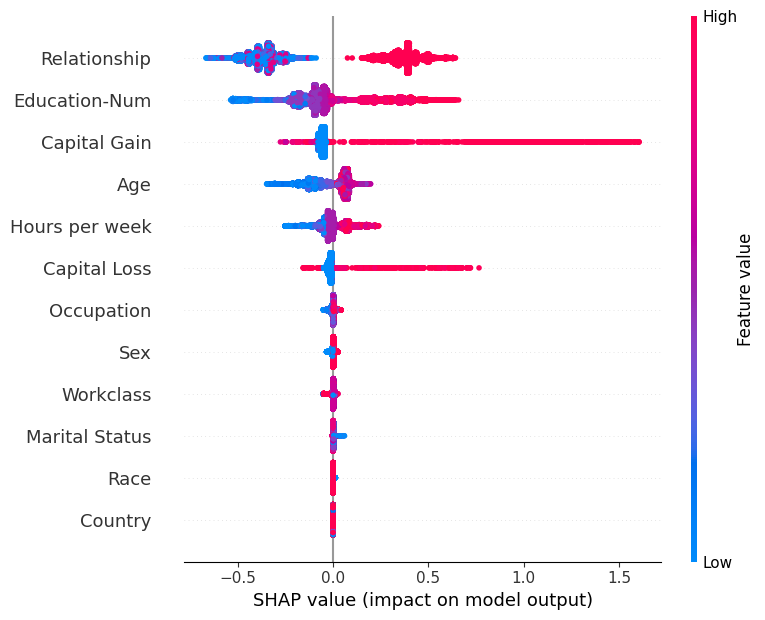

In [21]:
shap.summary_plot(shap_values, X)

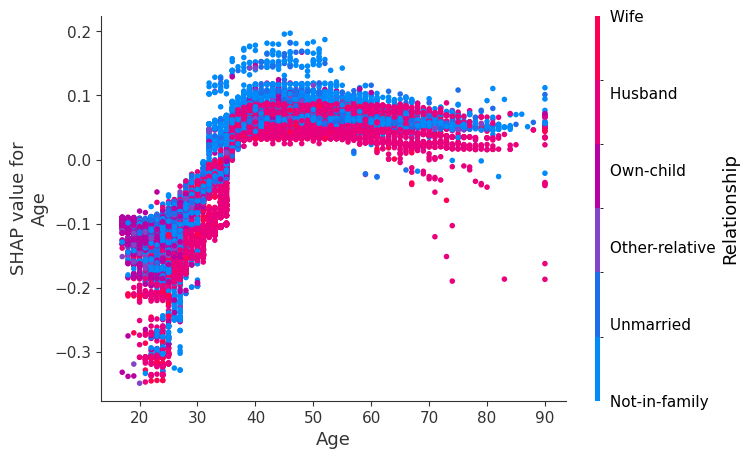

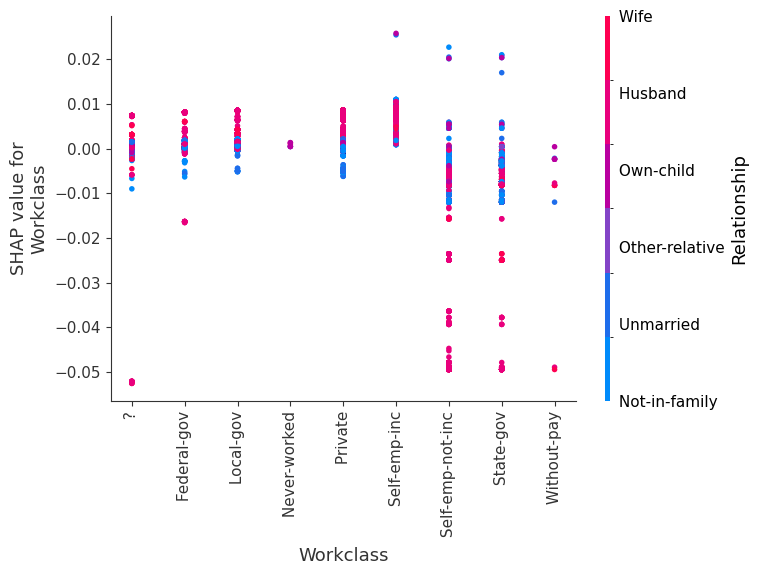

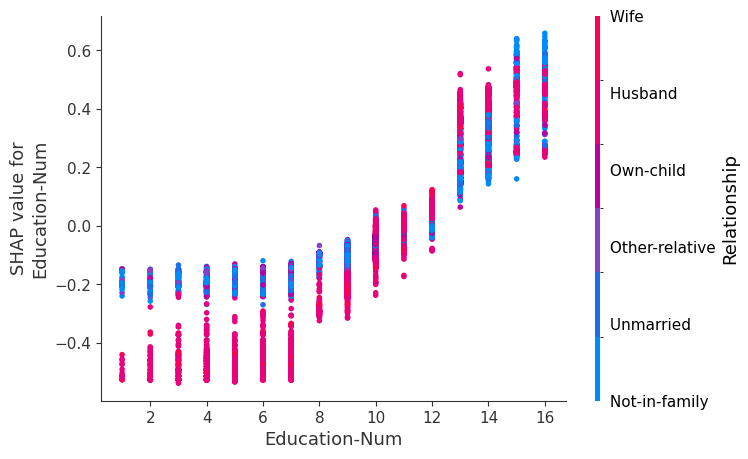

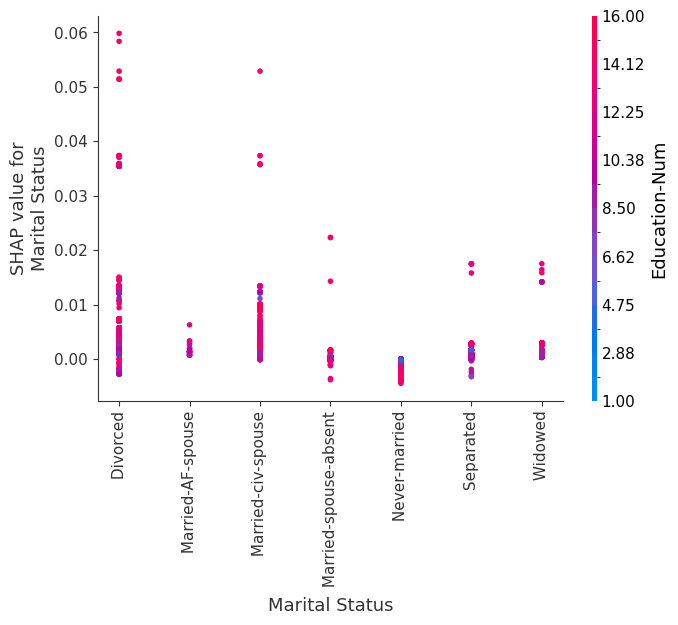

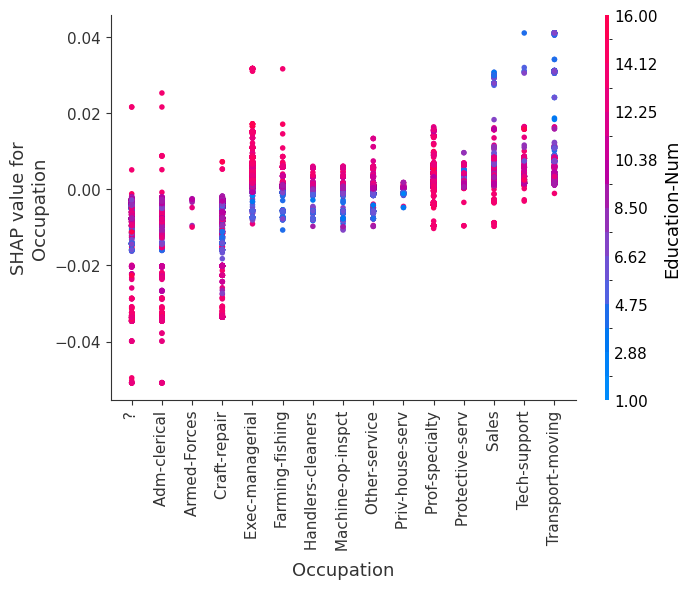

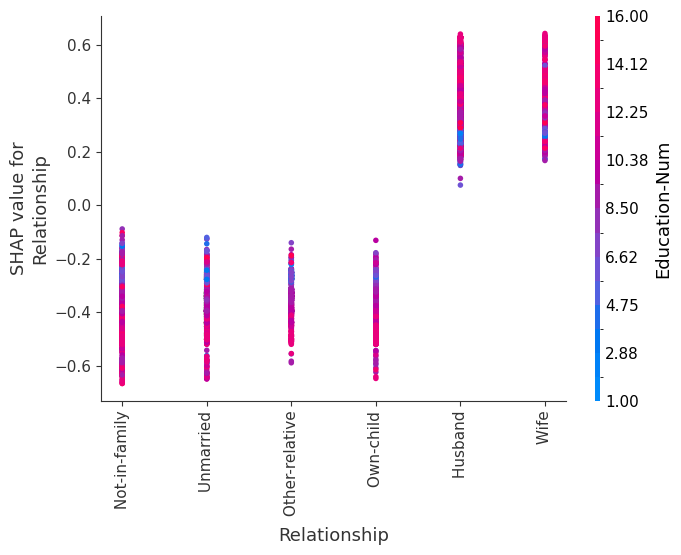

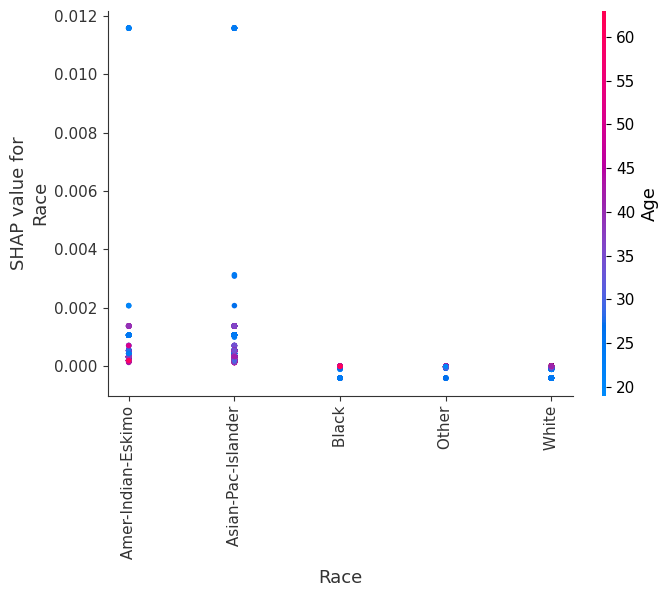

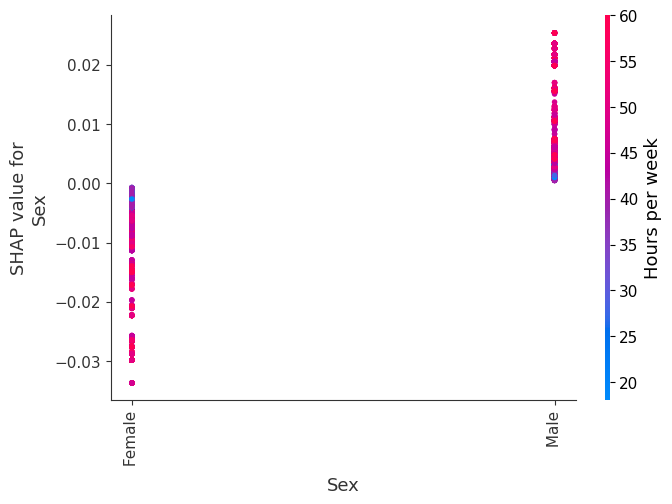

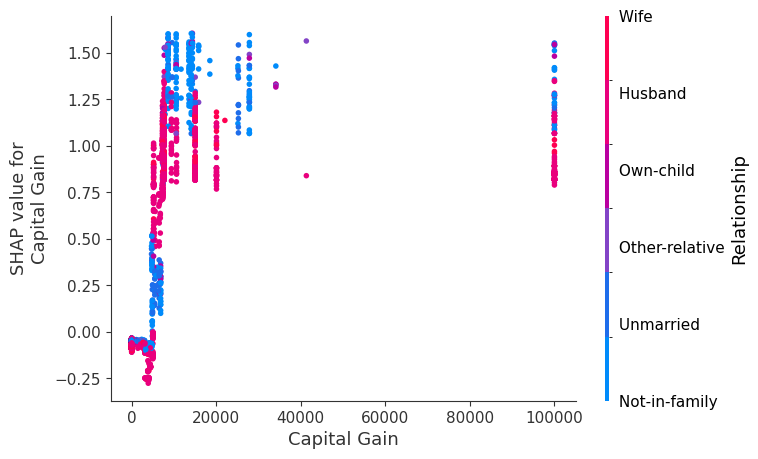

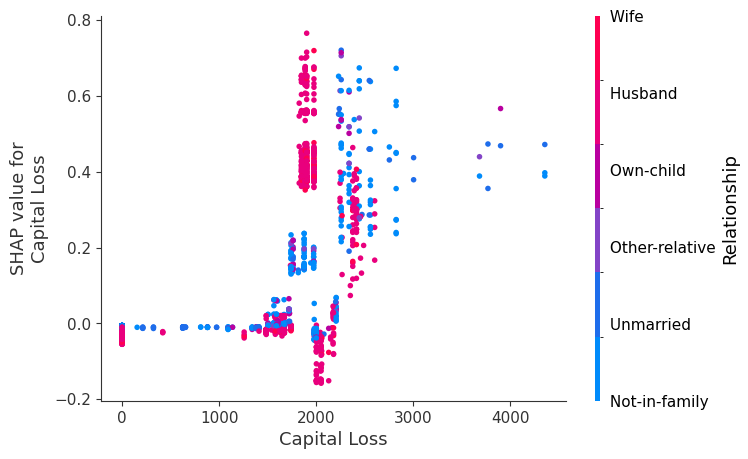

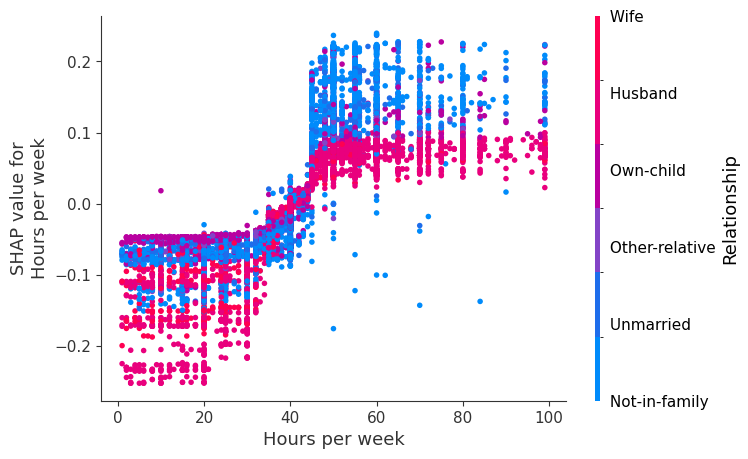

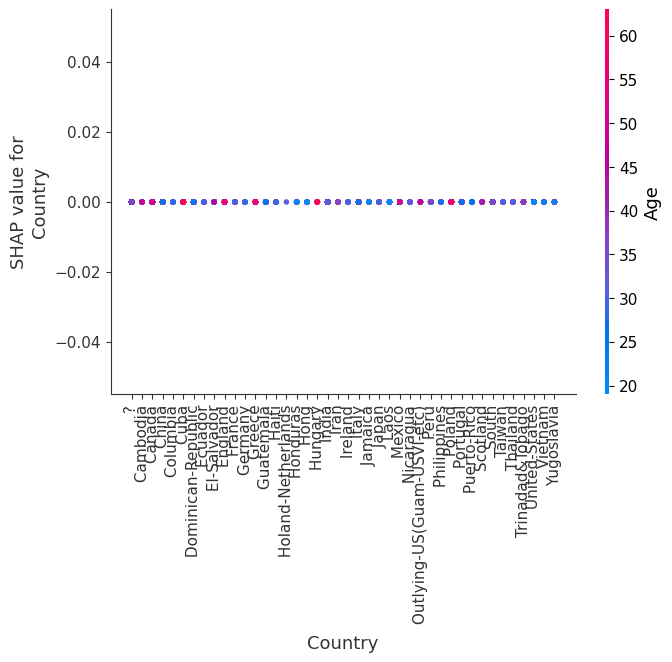

In [22]:
for name in X_train.columns:
  shap.dependence_plot(name, shap_values, X, display_features=X_display)